In [ ]:
# preprocessing package form the "toyxtoyproblem-af-classification" problem 

import sys
sys.path.append(r"C:\Users\saber\thesis_second_try\toyxtoyproblem-af-classification\ecg-preprocessing")


In [ ]:
from scipy.io import loadmat

path = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"
data = loadmat(path)


In [ ]:
from pathlib import Path

p = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat")
print("Exists:", p.exists())
print("Size (MB):", p.stat().st_size / 1e6)


In [ ]:
p = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"

with open(p, "rb") as f:
    head = f.read(128)

print(head[:32])
print(head)


In [ ]:
from scipy.io import loadmat

p = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"
mat = loadmat(p)

print("All keys:", list(mat.keys()))


In [ ]:
print([k for k in data.keys() if not k.startswith("__")])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

p = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"
mat = loadmat(p, squeeze_me=True, struct_as_record=False)

aggr = mat["aggr_data"]
print("type(aggr):", type(aggr))

# If it's a numeric array
if isinstance(aggr, np.ndarray) and np.issubdtype(aggr.dtype, np.number):
    print("aggr.shape:", aggr.shape, "dtype:", aggr.dtype)

    x = np.squeeze(aggr)

    # If 1D: plot directly
    if x.ndim == 1:
        plt.figure(figsize=(12,4))
        plt.plot(x[:2000])
        plt.title("aggr_data (first 2000 samples)")
        plt.xlabel("sample")
        plt.ylabel("value")
        plt.show()

    # If 2D: plot first column and a heatmap overview
    elif x.ndim == 2:
        plt.figure(figsize=(12,4))
        plt.plot(x[:2000, 0])
        plt.title("aggr_data[:,0] (first 2000 samples)")
        plt.xlabel("sample")
        plt.ylabel("value")
        plt.show()

        plt.figure(figsize=(8,5))
        plt.imshow(x.T, aspect="auto")
        plt.title("aggr_data heatmap (features/leads x time)")
        plt.xlabel("time/sample")
        plt.ylabel("channel/feature")
        plt.show()

    else:
        print("Numeric but unexpected ndim:", x.ndim)

# If it's a MATLAB struct-like object
elif hasattr(aggr, "_fieldnames"):
    print("aggr_data fields:", aggr._fieldnames)

    # Print shapes/types for each field
    for f in aggr._fieldnames:
        v = getattr(aggr, f)
        if isinstance(v, np.ndarray):
            print(f"{f}: array shape={v.shape}, dtype={v.dtype}")
        else:
            print(f"{f}: type={type(v)} value_preview={str(v)[:80]}")

    # Try to automatically pick a field to plot (largest numeric array)
    candidates = []
    for f in aggr._fieldnames:
        v = getattr(aggr, f)
        if isinstance(v, np.ndarray) and np.issubdtype(v.dtype, np.number):
            candidates.append((f, v.size))
    if candidates:
        best_field = sorted(candidates, key=lambda t: t[1], reverse=True)[0][0]
        x = np.squeeze(getattr(aggr, best_field))
        print("Auto-picked field to plot:", best_field, "shape:", x.shape)

        plt.figure(figsize=(12,4))
        if x.ndim == 1:
            plt.plot(x[:2000])
        elif x.ndim == 2:
            plt.plot(x[:2000, 0])
        else:
            print("Picked field has ndim:", x.ndim)
        plt.title(f"{best_field} (preview)")
        plt.show()
    else:
        print("No numeric arrays found inside aggr_data fields.")

else:
    # Fallback
    try:
        arr = np.array(aggr)
        print("Converted to array:", arr.shape, arr.dtype)
    except Exception as e:
        print("Could not interpret aggr_data:", e)


In [ ]:
import numpy as np
from scipy.io import loadmat

p = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"
mat = loadmat(p, squeeze_me=True, struct_as_record=False)
aggr = mat["aggr_data"]

def describe(obj, name="obj", depth=0, max_depth=4):
    indent = "  " * depth
    t = type(obj).__name__
    print(f"{indent}{name}: {t}")

    # MATLAB struct
    if hasattr(obj, "_fieldnames"):
        print(f"{indent}  fields: {obj._fieldnames}")
        if depth >= max_depth:
            return
        for f in obj._fieldnames:
            v = getattr(obj, f)
            describe(v, f"{name}.{f}", depth+1, max_depth)
        return

    # numpy array
    if isinstance(obj, np.ndarray):
        print(f"{indent}  array shape={obj.shape}, dtype={obj.dtype}")
        return

    # scalar / other
    print(f"{indent}  value preview: {str(obj)[:80]}")

describe(aggr, "aggr_data")


In [ ]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

p = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"
mat = loadmat(p, squeeze_me=True, struct_as_record=False)
aggr = mat["aggr_data"]

def extract_arrays(obj, prefix=""):
    out = {}
    if hasattr(obj, "_fieldnames"):  # MATLAB struct
        for f in obj._fieldnames:
            out.update(extract_arrays(getattr(obj, f), prefix + f + "_"))
    elif isinstance(obj, np.ndarray) and np.issubdtype(obj.dtype, np.number):
        out[prefix[:-1]] = np.squeeze(obj)
    return out

arrays = extract_arrays(aggr)
print("Found arrays:", arrays.keys())


i have converted rest pupil_preprocess in to cvs for each feature possibly unncessary.
TODO : what to do the next try to use the preprocessing file to preprocess the rest respiration 

In [ ]:
# from ecgprep.read_ecg import read_ecg
# import ecg_plot

# PATH_TO_WFDB = 'C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat'.
# ecg_sample, sample_rate, _ = read_ecg(PATH_TO_WFDB)

# # ECG plot
# plt.figure()

In [1]:
from pathlib import Path  # we have found all of the file form resting Respiration_ECG_Raw

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")
mat_files = sorted(folder.glob("*.mat"))

print("Number of .mat files:", len(mat_files))
print("all the files:")
for f in mat_files:
    print("  ", f.name)


Number of .mat files: 207
all the files:
   pupil_size_mm_estimation_LF.mat
   pupil_size_mm_interpolated_LF.mat
   resting_state_participant_010.mat
   resting_state_participant_011.mat
   resting_state_participant_012.mat
   resting_state_participant_013.mat
   resting_state_participant_014.mat
   resting_state_participant_015.mat
   resting_state_participant_016.mat
   resting_state_participant_017.mat
   resting_state_participant_018.mat
   resting_state_participant_019.mat
   resting_state_participant_020.mat
   resting_state_participant_021.mat
   resting_state_participant_022.mat
   resting_state_participant_023.mat
   resting_state_participant_024.mat
   resting_state_participant_025.mat
   resting_state_participant_026.mat
   resting_state_participant_027.mat
   resting_state_participant_028.mat
   resting_state_participant_029.mat
   resting_state_participant_030.mat
   resting_state_participant_031.mat
   resting_state_participant_033.mat
   resting_state_participant_034.mat

In [2]:
from scipy.io import loadmat   # picking one file to check 
import numpy as np

file_path = mat_files[4] 

print("Inspecting:", file_path.name)

mat = loadmat(file_path, squeeze_me=True, struct_as_record=False)

def find_arrays(obj, prefix=""):
    if hasattr(obj, "_fieldnames"):
        for f in obj._fieldnames:
            find_arrays(getattr(obj, f), prefix + f + ".")
    elif isinstance(obj, np.ndarray) and np.issubdtype(obj.dtype, np.number):
        print(prefix[:-1], "shape:", obj.shape)

for k in mat:
    if not k.startswith("__"):
        find_arrays(mat[k], k + ".")


Inspecting: resting_state_participant_012.mat
resting_state.Thermopod shape: (310058,)
resting_state.Cannula shape: (310058,)
resting_state.Fingerpulse shape: (310058,)
resting_state.ECG shape: (310058,)
resting_state.inhPeaks shape: (72,)
resting_state.exhPeaks shape: (72,)
resting_state.inhOnset shape: (72,)
resting_state.exhOnset shape: (72,)
resting_state.Phase shape: (304324,)
resting_state.inhPeaks_C shape: (70,)
resting_state.exhPeaks_C shape: (70,)
resting_state.inhOnset_C shape: (70,)
resting_state.exhOnset_C shape: (70,)
resting_state.Phase_C shape: (305293,)


In [3]:
import ecg_plot
import matplotlib.pyplot as plt
from ecgprep import preprocess, plot_helpers


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ecg_plot
import scipy
from scipy.io import loadmat
from scipy.signal import resample_poly
from ecgprep import preprocess

mat_path = r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw\resting_state_participant_012.mat"
m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
print(m)

ecg = np.asarray(m["resting_state"].Cannula).squeeze().reshape(1, -1)
fs = 1000
print(ecg)



{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Fri Feb  2 11:44:46 2024', '__version__': '1.0', '__globals__': [], 'resting_state': <scipy.io.matlab._mio5_params.mat_struct object at 0x0000020B608A28F0>}
[[ 0.0063657   0.00634184  0.0063175  ... -0.00168522 -0.00170331
  -0.00172155]]


# high-pass baseline filter 

--> Hade to move it up for the correct ordering ¨


In [57]:
import scipy.signal as sgn
# https://github.com/antonior92/ecg-preprocessing/blob/64a2715b15ea5ee1a482e5319d2cbaf45edef6f4/ecgprep/preprocess.py#L30C1-L40C15
def remove_baseline_filter(sample_rate):
    fc = 0.8   # Hz cutoff
    fst = 0.2  # Hz stopband edge
    rp = 0.5   # dB passband ripple
    rs = 40    # dB stopband attenuation

    wn = fc / (sample_rate / 2)
    wst = fst / (sample_rate / 2)

    order, _ = sgn.ellipord(wn, wst, rp, rs)
    sos = sgn.iirfilter(order, wn, rp, rs, btype="high", ftype="ellip", output="sos")
    return sos


import numpy as np

# ecg is shape (1, N)
sos = remove_baseline_filter(sample_rate=fs)
print( sos.shape)
# filter along the last axis (time)
ecg_baseline_removed = sgn.sosfiltfilt(sos, ecg, axis=-1)
print("ecg_60 shape:", ecg_baseline_removed)



(2, 6)
ecg_60 shape: [[0.0015415  0.00153041 0.00151891 ... 0.00021337 0.0001985  0.00018334]]


In [58]:

from scipy.signal import resample_poly

ecg_60 = resample_poly(ecg_baseline_removed, up=60, down=fs, axis=-1)
print("ecg_60 shape:", ecg_60.shape)


ecg_60 shape: (1, 18604)


# Resample everything to 60 Hz 

ecg_60 shape: (1, 18604)


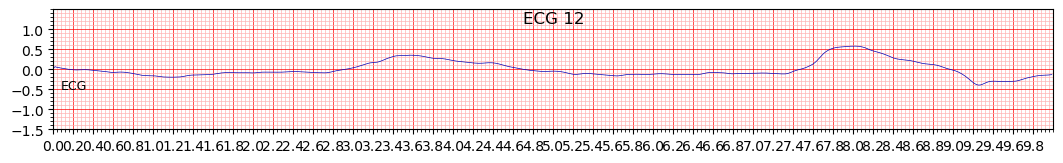

In [ ]:
ecg_60= scipy.signal.resample_poly(ecg, up=60, down=1000, axis=-1)


# OBS I Adjusted there from volt to minivolt
print("ecg_60 shape:", ecg_60.shape)

# scale for plotting: volts -> millivolts
# ecg *1000
# finger * 10
# Thermopod as is 
# Cannula * 10 
ecg_60_mv = ecg_60 * 10

import ecg_plot
import matplotlib.pyplot as plt

lead_index = ["ECG"] * ecg_60_mv.shape[0]

# plot a short window 
fs_out = 60
seconds = 10
n = fs_out * seconds

ecg_plot.plot(ecg_60_mv[:, :n], sample_rate=fs_out, lead_index=lead_index, style="b", columns=1)
plt.show()


# baseline filter

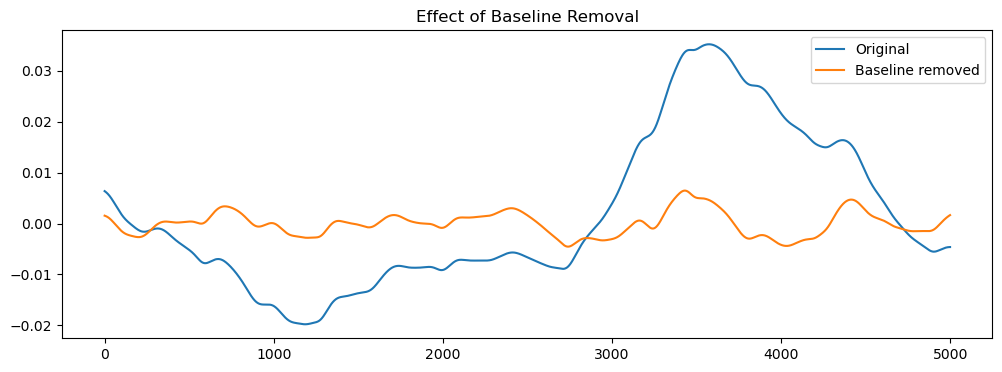

In [64]:
plt.figure(figsize=(12,4))
plt.plot(ecg[0, :5000], label="Original")
plt.plot(ecg_baseline_removed[0, :5000], label="Baseline removed")
plt.legend()
plt.title("Effect of Baseline Removal")
plt.show()


In [9]:
print("Min:", np.min(ecg_60))
print("Max:", np.max(ecg_60))
print("Mean:", np.mean(ecg_60))


Min: -0.00078565943972434
Max: 0.0018755603184463805
Mean: 0.0004004339318976625


the current ECG is in volt and we have to convert to millivolt ?????

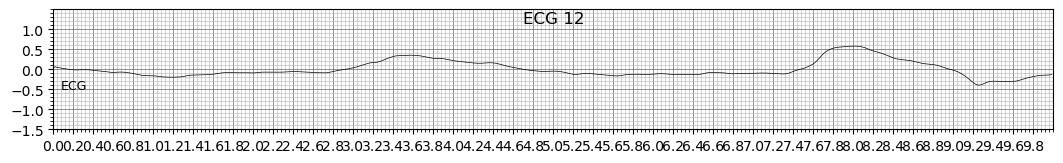

In [66]:
ecg_mv = ecg_60 * 10  # V -> mV

fs_out = 60 
seconds = 10
n = fs_out * seconds

import ecg_plot
ecg_plot.plot(ecg_mv[:, :n], sample_rate=fs_out, lead_index=["ECG"], style="bw", columns=1)
ecg_plot.show()


# spliting
- Window size 2048
- Number of windows = 18603 / 2048 = 9


In [ ]:
import numpy as np

x = ecg_60_mv[0]      # 1D ECG signal (in mV)
win_len = 2048

# stride = win_len → no overlap   
starts = np.arange(0, len(x) - win_len + 1, win_len) # TODO: UNDERSTAND THIS BETTER !! 

windows = np.stack([x[s:s+win_len] for s in starts])

print("windows shape:", windows.shape)   # should be (9, 2048)
print("leftover samples dropped:", len(x) - len(starts)*win_len)


windows shape: (9, 2048)
leftover samples dropped: 172


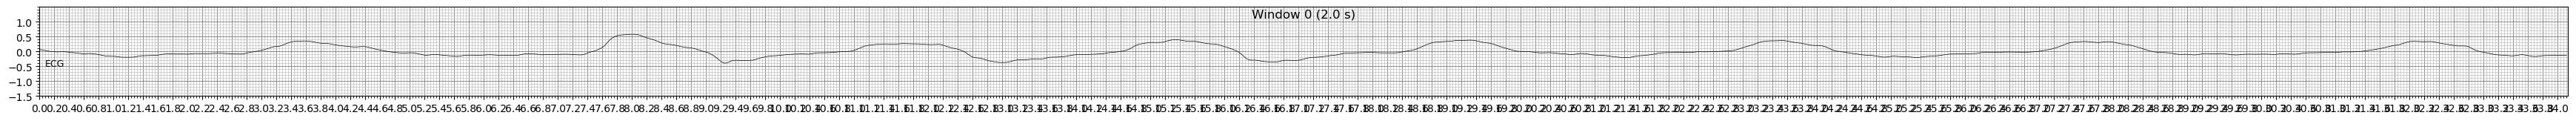

In [68]:
import ecg_plot
import matplotlib.pyplot as plt


i = 0  # choose window index

ecg_win = windows[i].reshape(1, -1)  # ecg_plot expects (leads, samples)

ecg_plot.plot(
    ecg_win,
    sample_rate=60,
    lead_index=["ECG"],
    style="bw",
    columns=1,
    title=f"Window {i} ({ecg_win.shape[1]/fs:.1f} s)"
)
plt.show()


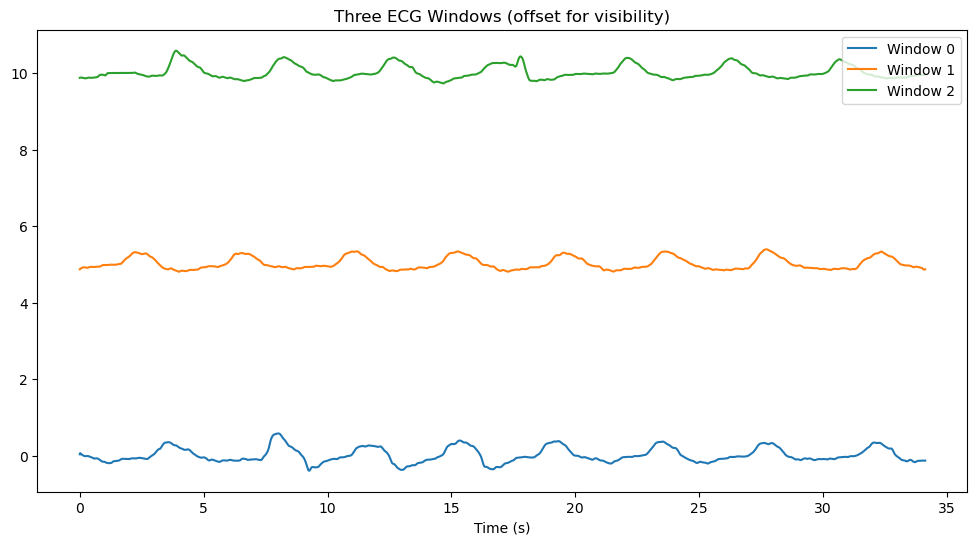

In [69]:
import matplotlib.pyplot as plt

fs = 60
t = np.arange(win_len) / fs

plt.figure(figsize=(12,6))

for i in range(min(3, len(windows))):
    plt.plot(t, windows[i] + i*5, label=f"Window {i}")  # offset for visibility

plt.xlabel("Time (s)")
plt.title("Three ECG Windows (offset for visibility)")
plt.legend()
plt.show()


I have preprossed one file form ecg! What to do next is TODO: 

- Do preprocessing for alla of the files NOW !!! 
- save all the preprocessed files in numpy dic tensor " tensor 9 x 4 x 2048 (n_windows x n_signals x window_size)"
---> stack in differe dimentionn, stack in top of it 
- what do you mean with the output 9X1 vecktor ??? 


Got answer about the scaling: 
---> have different scaling for each signal typ so that they look pretty much similare 
- ecg *1000
- finger * 10
- Thermopod as is 
- Cannula * 10 